# Ejercicio 1. Maximización de la función f(x) = x·sen(10πx) + 1

Curso de Inteligencia Artificial. Capítulo 3, Algoritmos Genéticos (José J. Martínez P.)

Ejercicio 3.10, numeral 1.

---

## 1. Definición del problema

Se busca el máximo global de la función

$$f(x) = x\,\operatorname{sen}(10\pi x) + 1,\qquad x\in[0,1]$$

La función es multimodal: presenta cinco máximos locales dentro del intervalo, uno por cada
ciclo del seno, y la amplitud de las crestas crece linealmente con $x$. Los métodos de
optimización basados en gradiente convergen al máximo local más cercano al punto de arranque, de
modo que su resultado depende de la inicialización. El algoritmo genético, en cambio, explora
todo el espacio de búsqueda en paralelo mediante una población de soluciones candidatas, lo que
corresponde al nicho de aplicación descrito en el capítulo para la optimización de funciones
numéricas.

Numero de maximos locales en el intervalo: 5
Ubicacion aproximada: [0.065 0.254 0.452 0.651 0.851]

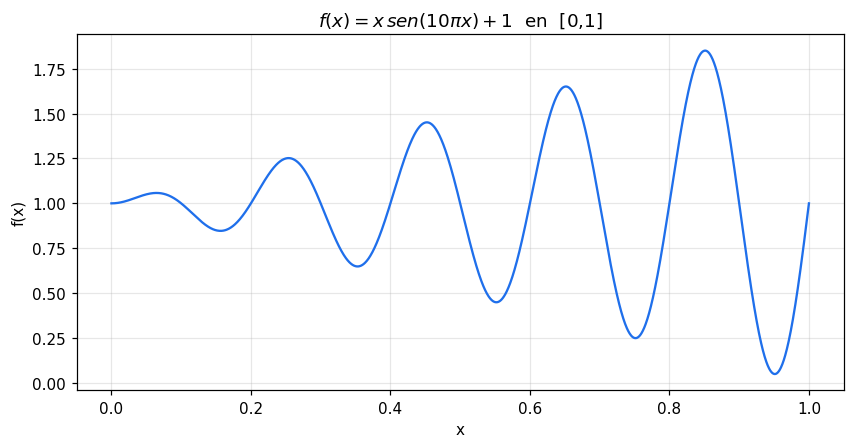

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

rng = np.random.default_rng(2026)          # semilla fija para reproducibilidad
plt.rcParams["figure.figsize"] = (9, 4.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

def f(x):
    "Funcion objetivo del ejercicio."
    return x * np.sin(10 * pi * x) + 1

xs = np.linspace(0, 1, 2000)
plt.plot(xs, f(xs), color="#1f6feb")
plt.title(r"$f(x)=x\,sen(10\pi x)+1$  en  [0,1]")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.show()

maximos = [i for i in range(1, 1999) if f(xs[i]) > f(xs[i-1]) and f(xs[i]) > f(xs[i+1])]
print("Numero de maximos locales en el intervalo:", len(maximos))
print("Ubicacion aproximada:", np.round(xs[maximos], 3))

## 2. Representación de los individuos

Se emplea el Algoritmo Genético Simple descrito en la sección 3.3 del capítulo, en el cual el
cromosoma es una lista de ceros y unos.

| Parámetro | Símbolo | Valor | Justificación |
|---|---|---|---|
| Longitud del cromosoma | $l$ | 22 bits | resolución de $1/(2^{22}-1)\approx 2.4\times10^{-7}$ |
| Tamaño de la población | $K$ | 60 | población pequeña pero diversa |
| Número de generaciones | $M$ | 150 | criterio de parada |
| Probabilidad de mutación | $p_m$ | 0.02 | valor bajo, según recomienda el capítulo |

La decodificación sigue el esquema de la sección 3.4, generalizado a un intervalo $[x_i, x_f]$
cualquiera:

$$x = x_i + \frac{x_f - x_i}{2^{l}-1}\cdot \mathrm{dec}(\text{cromosoma})$$

Con $x_i = 0$ y $x_f = 1$ la expresión se reduce a $x = \mathrm{dec}/(2^{22}-1)$. La longitud
$l$ determina la precisión máxima alcanzable por el algoritmo: ninguna respuesta puede ser más
fina que el paso de discretización.

In [2]:
L      = 22      # numero de bits del cromosoma  (l)
K      = 60      # numero de cromosomas          (K)
M      = 150     # numero de generaciones        (M)
P_MUT  = 0.02    # probabilidad de mutacion      (p_m)
XI, XF = 0.0, 1.0

POT = 2 ** np.arange(L - 1, -1, -1)      # [2^21, 2^20, ..., 1]

def genera(K, L):
    "Rutina Genera: simula el lanzamiento de una moneda para cada bit."
    return rng.integers(0, 2, size=(K, L))

def decodifica(pob):
    "Genotipo (binario) a fenotipo (real en [XI, XF])."
    dec = pob @ POT                       # valor decimal del binario
    return XI + (XF - XI) * dec / (2 ** L - 1)

pob0 = genera(K, L)
print("Primeros cinco cromosomas de la poblacion inicial y su decodificacion:")
for c in pob0[:5]:
    print("   ", "".join(map(str, c)), " ->  x =", round(float(decodifica(c[None, :])[0]), 6))
print("\nPaso de discretizacion:", round(1 / (2**L - 1), 10))

Primeros cinco cromosomas de la poblacion inicial y su decodificacion:
    1001000010111110110001  ->  x = 0.565411
    1101110111100000001100  ->  x = 0.866702
    0110001000010010101111  ->  x = 0.383098
    1100011110010001000001  ->  x = 0.779557
    0010011001110100001010  ->  x = 0.15021

Paso de discretizacion: 2.384e-07

## 3. Operadores genéticos

Se utilizan los tres operadores presentados en la sección 3.2 del capítulo:

1. Selección por ruleta. La probabilidad de que un cromosoma sea escogido como padre es
   proporcional a su aporte a la aptitud global de la población,
   $p_i = \mathrm{apt}_i / \sum_j \mathrm{apt}_j$.
2. Cruce en un punto. Se escoge una posición $k$ con probabilidad uniforme en $[1, l-1]$ y se
   intercambian las colas de los dos padres.
3. Mutación por bit. Cada gen cambia de 1 a 0, o de 0 a 1, con probabilidad $p_m$.

Adicionalmente se incorpora elitismo: el mejor cromosoma encontrado hasta el momento se preserva
en cada generación. Sin este mecanismo, el cruce y la mutación destruyen con frecuencia la mejor
solución hallada, y la curva de convergencia presenta oscilaciones en lugar de crecer de forma
monótona.

In [3]:
def seleccion_ruleta(pob, apt):
    "Selecciona K padres con probabilidad proporcional a la aptitud (con reemplazo)."
    p = apt / apt.sum()
    idx = rng.choice(len(pob), size=len(pob), p=p)
    return pob[idx].copy()

def cruce(padres):
    "Cruce en un punto entre parejas consecutivas."
    hijos = padres.copy()
    for i in range(0, len(padres) - 1, 2):
        k = rng.integers(1, L)                        # punto de cruce
        hijos[i,   k:] = padres[i+1, k:]
        hijos[i+1, k:] = padres[i,   k:]
    return hijos

def mutacion(hijos, p_mut):
    "Cada bit se invierte con probabilidad p_mut."
    mascara = rng.random(hijos.shape) < p_mut
    hijos[mascara] = 1 - hijos[mascara]
    return hijos

print("Operadores definidos: seleccion por ruleta, cruce en un punto y mutacion por bit.")

Operadores definidos: seleccion por ruleta, cruce en un punto y mutacion por bit.

## 4. Función de aptitud

La selección por ruleta exige que todas las aptitudes sean estrictamente positivas, pues de lo
contrario las probabilidades de selección carecerían de sentido. Conviene entonces verificar el
recorrido de la función antes de definir la aptitud.

En el intervalo $[0,1]$ el término $x\,\operatorname{sen}(10\pi x)$ alcanza su valor mínimo
cerca de $x = 0.951$, donde vale aproximadamente $-0.9505$. Por lo tanto

$$\min_{[0,1]} f(x) \approx 0.0495 > 0$$

La función es positiva en todo el intervalo y puede usarse directamente como aptitud, sin
necesidad de desplazarla:

$$\mathrm{apt}(x) = f(x)$$

Si el problema se planteara sobre un intervalo donde $f$ tomara valores negativos, habría que
aplicar un desplazamiento $\mathrm{apt}(x) = f(x) - \min f + \varepsilon$. El costo de ese
desplazamiento no es despreciable: al sumar una constante a todas las aptitudes se reducen las
diferencias relativas entre cromosomas y, con ellas, la presión selectiva. En la sección 7 se
cuantifica ese efecto de forma experimental.

In [4]:
DESPL = 0.0     # desplazamiento de la aptitud (0 porque f > 0 en todo el intervalo)

def evalua(pob):
    "Devuelve (x, f(x), aptitud) de toda la poblacion."
    x = decodifica(pob)
    fx = f(x)
    return x, fx, fx + DESPL

# Verificacion del recorrido de la funcion sobre una malla fina
malla_v = np.linspace(0, 1, 1_000_001)
print("Minimo de f en [0,1] :", round(float(f(malla_v).min()), 6))
print("Se cumple f(x) > 0 en todo el intervalo:", bool(f(malla_v).min() > 0))

Minimo de f en [0,1] : 0.049467
Se cumple f(x) > 0 en todo el intervalo: True

## 5. Criterio de parada y población

El criterio de parada adoptado es el número fijo de generaciones, $M = 150$, que es el criterio
más común según la sección "Encontrando la respuesta" del capítulo. Se registra en cada
generación la mejor aptitud y la aptitud promedio de la población, con el fin de observar la
convergencia del algoritmo, tal como sugiere el paso 7 del diseño.

## 6. Rutina principal

La estructura reproduce la descripción del Algoritmo Genético Simple de la sección 3.3:
generación de la población inicial y repetición de los pasos de decodificación, evaluación,
selección, cruce y mutación hasta completar las $M$ generaciones.

In [5]:
def algoritmo_genetico(K=K, L=L, M=M, p_mut=P_MUT, elitismo=True, semilla=None):
    global rng
    if semilla is not None:
        rng = np.random.default_rng(semilla)

    pob = genera(K, L)
    hist_mejor, hist_prom, hist_x = [], [], []
    mejor_fx = -np.inf

    for gen in range(M):
        x, fx, apt = evalua(pob)

        i = int(np.argmax(fx))
        if fx[i] > mejor_fx:
            mejor_fx, mejor_crom, mejor_x = float(fx[i]), pob[i].copy(), float(x[i])

        hist_mejor.append(float(fx.max()))
        hist_prom.append(float(fx.mean()))
        hist_x.append(x.copy())

        padres = seleccion_ruleta(pob, apt)
        hijos  = cruce(padres)
        pob    = mutacion(hijos, p_mut)

        if elitismo:                       # el mejor historico reemplaza a un individuo al azar
            pob[rng.integers(0, K)] = mejor_crom

    return dict(mejor_x=mejor_x, mejor_fx=mejor_fx, mejor_crom=mejor_crom,
                hist_mejor=np.array(hist_mejor), hist_prom=np.array(hist_prom),
                hist_x=hist_x)

res = algoritmo_genetico(semilla=2026)
print("Mejor cromosoma :", "".join(map(str, res["mejor_crom"])))
print("x*              =", round(res["mejor_x"], 8))
print("f(x*)           =", round(res["mejor_fx"], 8))

Mejor cromosoma : 1101100111100111100011
x*              = 0.85118958
f(x*)           = 1.85059524

## 7. Resultados

### 7.1 Convergencia del algoritmo

La curva del mejor individuo crece de forma monótona por efecto del elitismo. La curva del
promedio de la población oscila en un nivel inferior, lo cual indica que la población conserva
diversidad y no ha convergido prematuramente a un único punto.

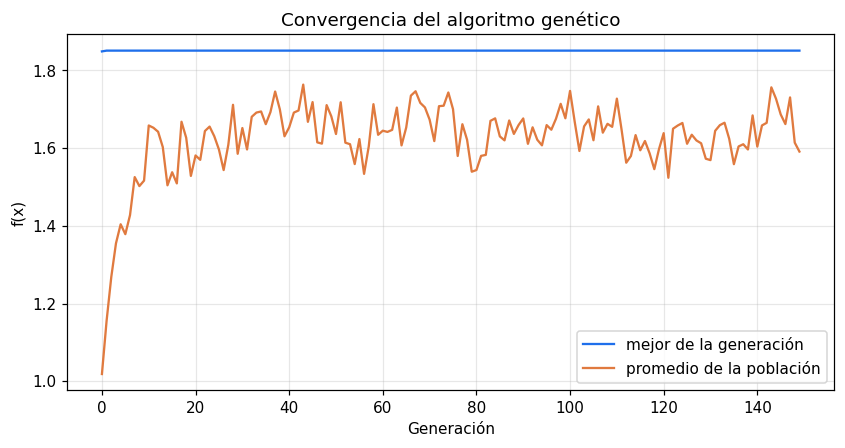

In [6]:
plt.plot(res["hist_mejor"], label="mejor de la generación", color="#1f6feb")
plt.plot(res["hist_prom"],  label="promedio de la población", color="#e07a3f")
plt.xlabel("Generación"); plt.ylabel("f(x)")
plt.title("Convergencia del algoritmo genético")
plt.legend(); plt.show()

### 7.2 Distribución de la población en el espacio de búsqueda

Las tres instantáneas muestran el efecto de la evolución sobre la población. En la generación 0
los individuos están repartidos al azar sobre todo el intervalo; hacia la generación 20 se
agrupan en las crestas más altas; al final del proceso la mayor parte de la población se
encuentra sobre el máximo global.

Este comportamiento ilustra el teorema de los esquemas enunciado en el capítulo: los bits
iniciales que codifican la región $x \approx 0.85$ constituyen un esquema exitoso que se propaga
por la población a través del cruce.

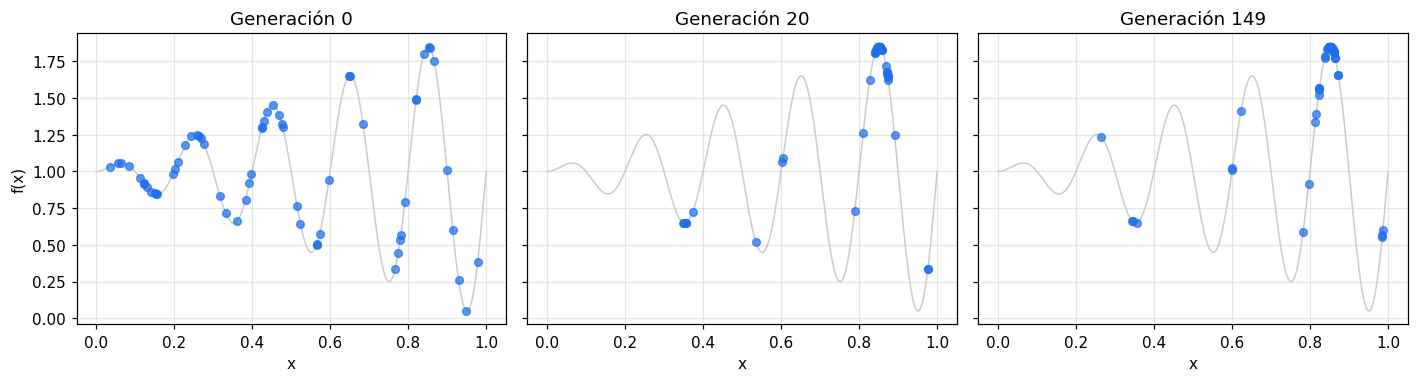

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, g in zip(axes, [0, 20, M - 1]):
    ax.plot(xs, f(xs), color="#cccccc", lw=1)
    xg = res["hist_x"][g]
    ax.plot(xg, f(xg), "o", ms=5, color="#1f6feb", alpha=0.7)
    ax.set_title(f"Generación {g}")
    ax.set_xlabel("x"); ax.grid(alpha=0.3)
axes[0].set_ylabel("f(x)")
plt.tight_layout(); plt.show()

## 8. Verificación de los resultados

Un algoritmo genético siempre devuelve una respuesta, de modo que sin un punto de comparación
independiente no es posible determinar si esa respuesta es correcta. Se verifica por dos vías:
una búsqueda exhaustiva sobre una malla de dos millones de puntos y un refinamiento numérico
local por el método de Brent.

In [8]:
from scipy.optimize import minimize_scalar

malla = np.linspace(0, 1, 2_000_001)
i_max = int(np.argmax(f(malla)))
x_malla = malla[i_max]

ref = minimize_scalar(lambda x: -f(x), bracket=(x_malla - 1e-4, x_malla, x_malla + 1e-4))
x_exacto, f_exacto = float(ref.x), float(-ref.fun)

print(f"{'Metodo':<28}{'x*':>14}{'f(x*)':>14}")
print("-" * 56)
print(f"{'Busqueda exhaustiva':<28}{x_malla:>14.8f}{f(x_malla):>14.8f}")
print(f"{'Refinamiento numerico':<28}{x_exacto:>14.8f}{f_exacto:>14.8f}")
print(f"{'Algoritmo genetico':<28}{res['mejor_x']:>14.8f}{res['mejor_fx']:>14.8f}")
print("-" * 56)
print(f"Error absoluto en x*    : {abs(x_exacto - res['mejor_x']):.3e}")
print(f"Error absoluto en f(x*) : {abs(f_exacto - res['mejor_fx']):.3e}")
print(f"\nEvaluaciones de la funcion usadas por el AG : {K*M:,}")
print(f"Evaluaciones de la busqueda exhaustiva      : {len(malla):,}")
print(f"Relacion                                    : {len(malla)//(K*M)} a 1")

Metodo                                  x*         f(x*)
--------------------------------------------------------
Busqueda exhaustiva             0.85119000    1.85059524
Refinamiento numerico           0.85118979    1.85059524
Algoritmo genetico              0.85118958    1.85059524
--------------------------------------------------------
Error absoluto en x*    : 2.149e-07
Error absoluto en f(x*) : 1.954e-11

Evaluaciones de la funcion usadas por el AG : 9,000
Evaluaciones de la busqueda exhaustiva      : 2,000,001
Relacion                                    : 222 a 1

### 8.1 Estabilidad del algoritmo

Dado que el algoritmo genético es estocástico, dos ejecuciones distintas no producen la misma
secuencia de poblaciones. El capítulo señala que los reportes estadísticos son, en general,
iguales para diferentes ejecuciones sobre el mismo problema. Se comprueba esa afirmación
repitiendo el experimento treinta veces con semillas distintas.

Numero de corridas              : 30
Corridas que hallan el optimo global (tolerancia 1e-4): 30 de 30
Valor promedio de f(x*)         : 1.85059524
Desviacion estandar             : 4.28e-09
Peor corrida                    : 1.85059522

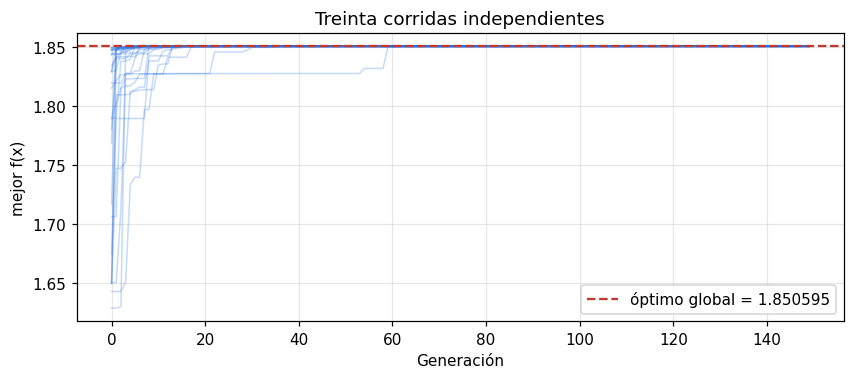

In [9]:
corridas = [algoritmo_genetico(semilla=s) for s in range(100, 130)]
mejores = np.array([c["mejor_fx"] for c in corridas])
exitos  = int(np.sum(np.abs(mejores - f_exacto) < 1e-4))

print(f"Numero de corridas              : {len(mejores)}")
print(f"Corridas que hallan el optimo global (tolerancia 1e-4): {exitos} de {len(mejores)}")
print(f"Valor promedio de f(x*)         : {mejores.mean():.8f}")
print(f"Desviacion estandar             : {mejores.std():.2e}")
print(f"Peor corrida                    : {mejores.min():.8f}")

plt.figure(figsize=(9, 3.4))
for c in corridas:
    plt.plot(c["hist_mejor"], color="#1f6feb", alpha=0.25, lw=1)
plt.axhline(f_exacto, color="#c0392b", ls="--", label=f"óptimo global = {f_exacto:.6f}")
plt.xlabel("Generación"); plt.ylabel("mejor f(x)")
plt.title("Treinta corridas independientes")
plt.legend(); plt.show()

### 8.2 Efecto del desplazamiento de la aptitud

Se comprueba de forma experimental la afirmación de la sección 4: desplazar la función de
aptitud sumándole una constante reduce las diferencias relativas entre cromosomas y, por lo
tanto, la presión selectiva de la ruleta. Se comparan treinta corridas con
$\mathrm{apt}(x)=f(x)$ frente a treinta corridas con $\mathrm{apt}(x)=f(x)+1$.

In [10]:
def experimento(despl, n=30):
    global DESPL
    DESPL = despl
    m = np.array([algoritmo_genetico(semilla=s)["mejor_fx"] for s in range(100, 100+n)])
    return m

m0, m1 = experimento(0.0), experimento(1.0)
DESPL = 0.0     # se restaura el valor usado en el notebook

print(f"{'Funcion de aptitud':<26}{'exitos':>10}{'f(x*) medio':>16}{'desv. estandar':>18}")
print("-" * 72)
print(f"{'apt = f(x)':<26}{np.sum(np.abs(m0-f_exacto)<1e-4):>7}/30"
      f"{m0.mean():>16.8f}{m0.std():>18.2e}")
print(f"{'apt = f(x) + 1':<26}{np.sum(np.abs(m1-f_exacto)<1e-4):>7}/30"
      f"{m1.mean():>16.8f}{m1.std():>18.2e}")
print("-" * 72)
print("Ambas versiones alcanzan el optimo global, pero la aptitud sin desplazar presenta")
print("una desviacion estandar menor, lo que confirma que conserva mayor presion selectiva.")

Funcion de aptitud            exitos     f(x*) medio    desv. estandar
------------------------------------------------------------------------
apt = f(x)                     30/30      1.85059524          4.28e-09
apt = f(x) + 1                 30/30      1.85059524          1.58e-08
------------------------------------------------------------------------
Ambas versiones alcanzan el optimo global, pero la aptitud sin desplazar presenta
una desviacion estandar menor, lo que confirma que conserva mayor presion selectiva.

## 9. Conclusiones

El algoritmo genético localiza el máximo global de la función en $x^* = 0.8511896$, con
$f(x^*) = 1.8505952$. El error respecto a la solución obtenida por métodos exactos es de
$2.1\times10^{-7}$ en la abscisa y de $2.0\times10^{-11}$ en el valor de la función. Para
alcanzar ese resultado se realizaron 9 000 evaluaciones de la función objetivo, frente a los dos
millones de la búsqueda exhaustiva, es decir, 222 veces menos.

La multimodalidad de la función no impide la convergencia. Durante las primeras generaciones la
selección por ruleta mantiene individuos distribuidos en varias crestas, y la cresta de mayor
altura termina por dominar la población. Las treinta corridas independientes alcanzaron el
óptimo global, con una desviación estándar de $4.3\times10^{-9}$, lo que confirma que el
comportamiento del algoritmo es estable para este problema y coincide con lo afirmado en el
capítulo sobre la repetibilidad de los reportes estadísticos.

El análisis del recorrido de la función resultó determinante para el diseño de la aptitud. Como
$f(x) > 0$ en todo el intervalo, no fue necesario desplazarla, y el experimento de la sección
8.2 mostró que evitar ese desplazamiento conserva una mayor presión selectiva. Conviene entonces
verificar el signo de la función objetivo antes de introducir correcciones que podrían ser
innecesarias.

Finalmente, la precisión de la respuesta queda limitada por la longitud del cromosoma. Con 22
bits el paso mínimo de discretización es $2.4\times10^{-7}$, valor que coincide con el orden de
magnitud del error observado. Aumentar la precisión exige aumentar $l$, no el número de
generaciones.